# Customer Behavior Analysis - Data Preparation & EDA
Nama: Sandya Gifta

Dataset: Superstore Inc

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('02_Raw_Dataset_Cleaned.csv')
print('Jumlah baris:', len(df))
df.head()

Jumlah baris: 9993


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
print('Baris dengan Postal Code kosong:', df['Postal Code'].isnull().sum())
df[df['Postal Code'].isnull()]

Baris dengan Postal Code kosong: 11


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2234,2235,CA-2018-104066,12/5/2018,12/10/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,7,0.0,67.6599
5273,5275,CA-2016-162887,11/7/2016,11/9/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,...,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,3,0.0,178.8000
8797,8799,US-2017-150140,4/6/2017,4/10/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,...,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,5,0.0,336.6350
9145,9147,US-2017-165505,1/23/2017,1/27/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2,0.0,42.9914
9146,9148,US-2017-165505,1/23/2017,1/27/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,6,0.0,2.7336
9147,9149,US-2017-165505,1/23/2017,1/27/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,13,0.0,406.7154
9385,9387,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,4,0.0,37.5624
9386,9388,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,1,0.0,5.7716
9387,9389,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,3,0.0,152.0232
9388,9390,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,1,0.0,0.9588


In [10]:
df[df['Postal Code'].isnull()][['Row ID', 'City', 'State']]

,Row ID,City,State
2234,2235,Burlington,Vermont
5273,5275,Burlington,Vermont
8797,8799,Burlington,Vermont
9145,9147,Burlington,Vermont
9146,9148,Burlington,Vermont
9147,9149,Burlington,Vermont
9385,9387,Burlington,Vermont
9386,9388,Burlington,Vermont
9387,9389,Burlington,Vermont
9388,9390,Burlington,Vermont


In [11]:
df.loc[df['City']=='Burlington', 'Postal Code'] = 5401
print('Sisa Postal Code kosong:', df['Postal Code'].isnull().sum())

Sisa Postal Code kosong: 0


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df['Postal Code'] = df['Postal Code'].astype(int).astype(str)
df['Quantity'] = df['Quantity'].astype(int)
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [13]:
print('Baris dengan Ship Date < Order Date:', (df['Ship Date'] < df['Order Date']).sum())
print('Baris dengan Quantity <= 0:', (df['Quantity'] <= 0).sum())
print('Baris dengan Discount di luar 0-1:', ((df['Discount']<0)|(df['Discount']>1)).sum())
print('Baris dengan Profit negatif:', (df['Profit']<0).sum())

Baris dengan Ship Date < Order Date: 0
Baris dengan Quantity <= 0: 0
Baris dengan Discount di luar 0-1: 0
Baris dengan Profit negatif: 1870


In [14]:
for col in ['Ship Mode','Segment','Region','Category','Sub-Category']:
    print(col, ':', df[col].unique())

Ship Mode : ['Second Class' 'Standard Class' 'First Class' 'Same Day']
Segment : ['Consumer' 'Corporate' 'Home Office']
Region : ['South' 'West' 'Central' 'East']
Category : ['Furniture' 'Office Supplies' 'Technology']
Sub-Category : ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


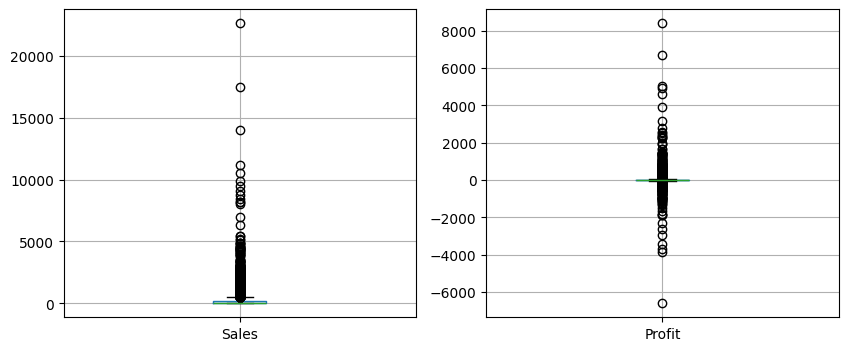

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(10,4))
df.boxplot(column='Sales', ax=axes[0])
df.boxplot(column='Profit', ax=axes[1])
plt.show()

In [16]:
df.to_csv('03_Clean_Dataset.csv', index=False)
from google.colab import files
files.download('03_Clean_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('03_Clean_Dataset.csv', parse_dates=['Order Date', 'Ship Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [18]:
# Statistik deskriptif kolom numerik
df[['Sales','Quantity','Discount','Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9993.000000,9993.000000,9993.000000,9993.000000
mean,229.852846,3.789753,0.156188,28.660971
std,623.276074,2.225149,0.206457,234.271476
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.731000
50%,54.480000,3.000000,0.200000,8.671000
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


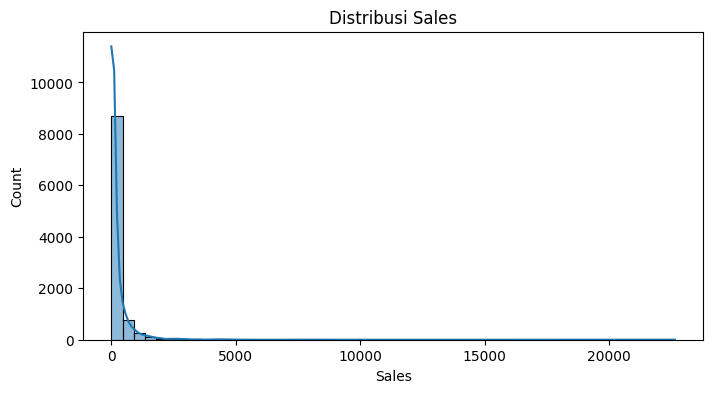

In [19]:
# Visualisasi 1: Distribusi Sales
plt.figure(figsize=(8,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribusi Sales')
plt.show()

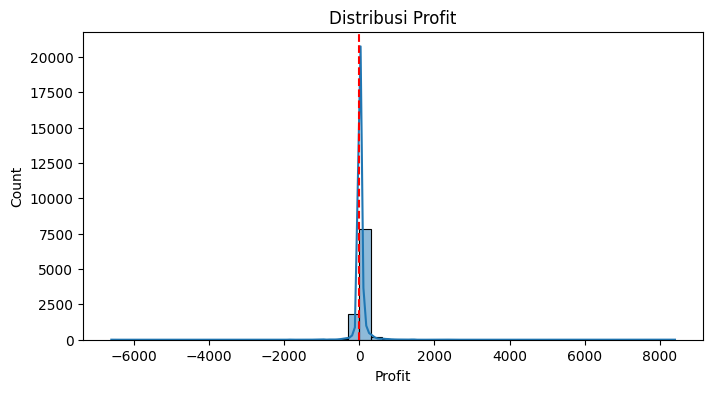

In [20]:
# Visualisasi 2: Distribusi Profit
plt.figure(figsize=(8,4))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title('Distribusi Profit')
plt.axvline(0, color='red', linestyle='--')
plt.show()

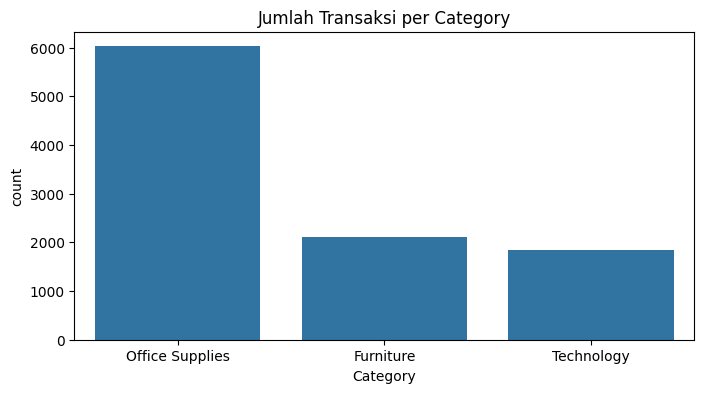

In [21]:
# Visualisasi 3: Distribusi Category
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)
plt.title('Jumlah Transaksi per Category')
plt.show()

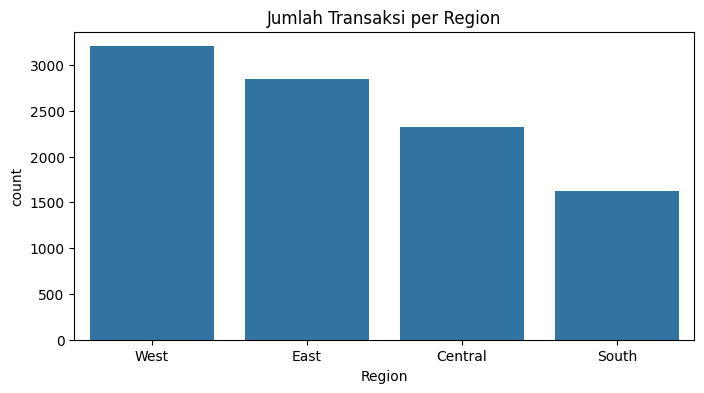

In [22]:
# Visualisasi 4: Distribusi Region
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Region', order=df['Region'].value_counts().index)
plt.title('Jumlah Transaksi per Region')
plt.show()

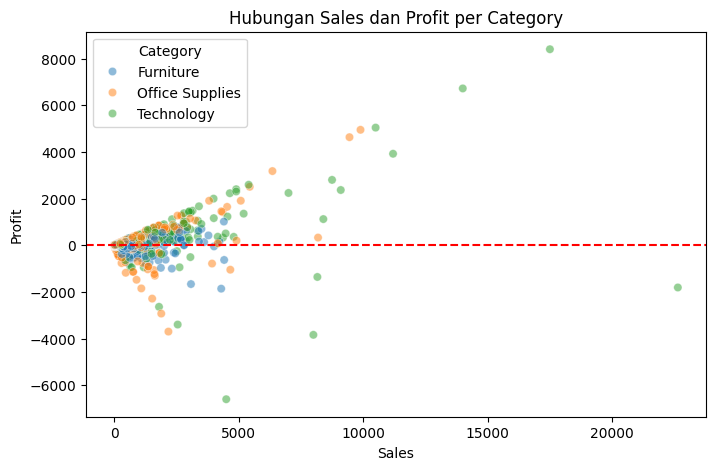

In [23]:
# Visualisasi 5: Hubungan Sales vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.5)
plt.title('Hubungan Sales dan Profit per Category')
plt.axhline(0, color='red', linestyle='--')
plt.show()

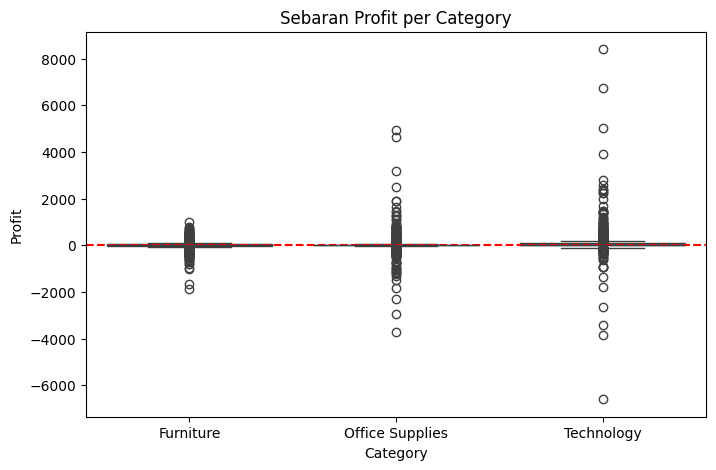

In [24]:
# Visualisasi 6: Sebaran Profit per Category
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Sebaran Profit per Category')
plt.axhline(0, color='red', linestyle='--')
plt.show()

/tmp/ipykernel_621/2944641704.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('Order Date').resample('M')['Sales'].sum()


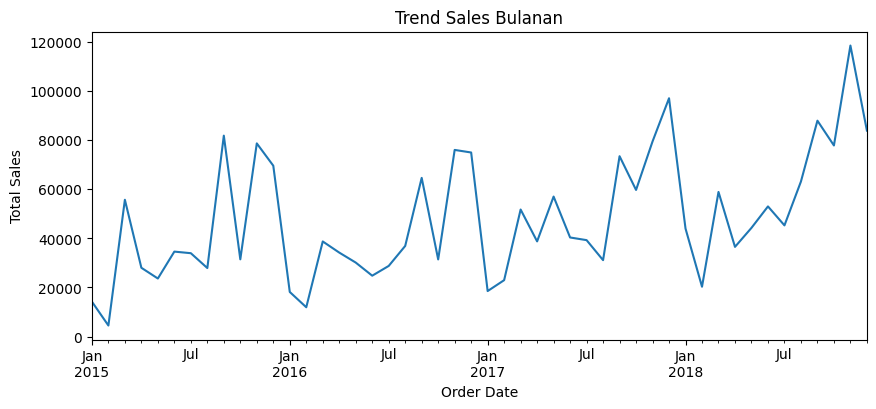

In [25]:
# Visualisasi 7: Trend Sales bulanan
df_monthly = df.set_index('Order Date').resample('M')['Sales'].sum()
plt.figure(figsize=(10,4))
df_monthly.plot()
plt.title('Trend Sales Bulanan')
plt.ylabel('Total Sales')
plt.show()

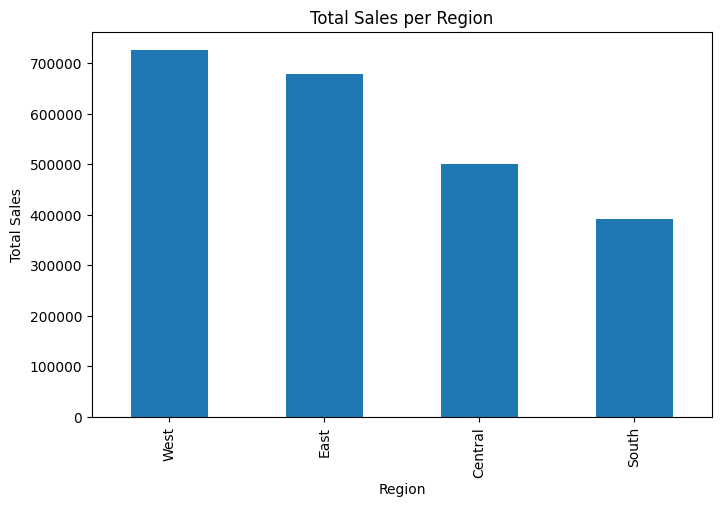

In [26]:
# Visualisasi 8: Total Sales per Region
plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales per Region')
plt.ylabel('Total Sales')
plt.show()

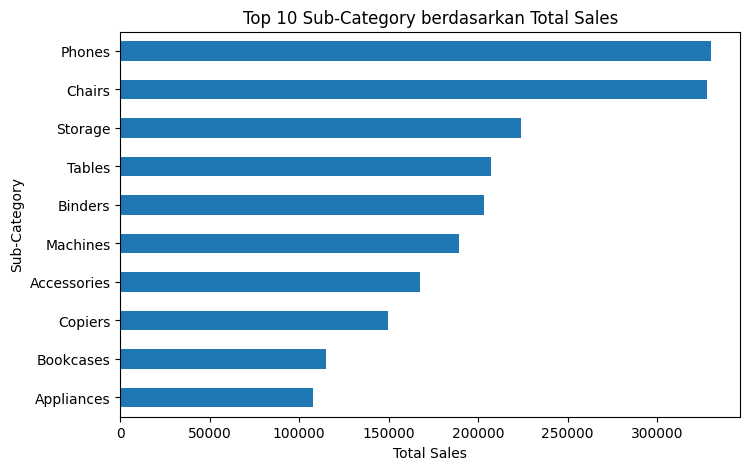

In [27]:
# Visualisasi 9: Top 10 Sub-Category berdasarkan Sales
plt.figure(figsize=(8,5))
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Sub-Category berdasarkan Total Sales')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.show()

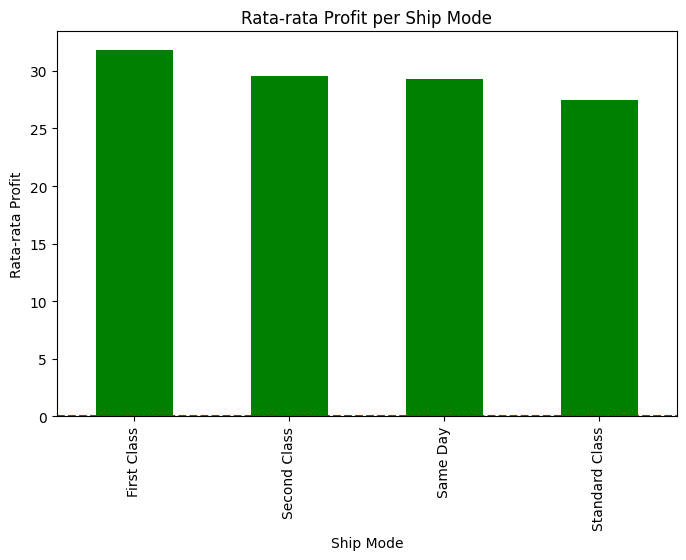

In [28]:
# Visualisasi 10: Rata-rata Profit per Ship Mode
plt.figure(figsize=(8,5))
df.groupby('Ship Mode')['Profit'].mean().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Rata-rata Profit per Ship Mode')
plt.ylabel('Rata-rata Profit')
plt.axhline(0, color='red', linestyle='--')
plt.show()

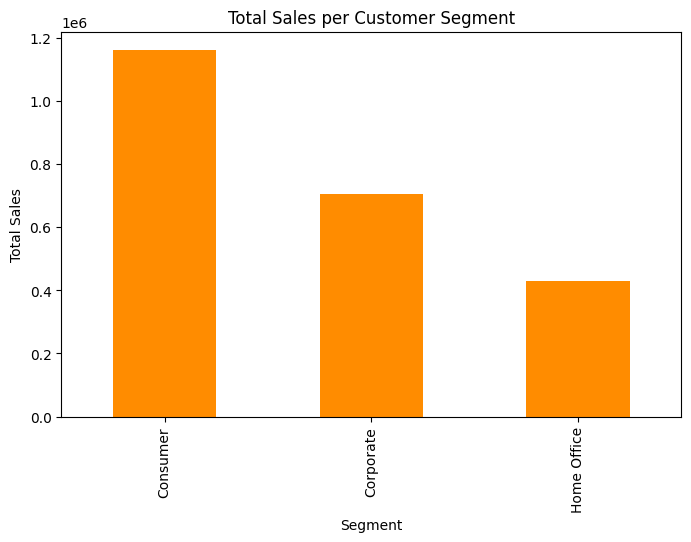

In [29]:
# Visualisasi 11: Total Sales per Customer Segment
plt.figure(figsize=(8,5))
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='darkorange')
plt.title('Total Sales per Customer Segment')
plt.ylabel('Total Sales')
plt.show()

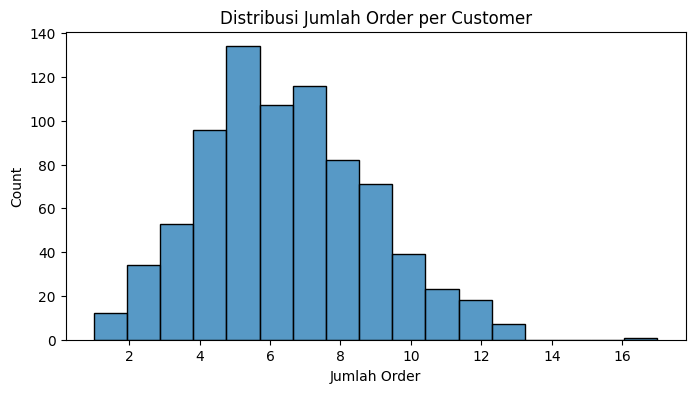

In [30]:
# Visualisasi 12: Distribusi Jumlah Order per Customer
orders_per_cust = df.groupby('Customer ID')['Order ID'].nunique()
plt.figure(figsize=(8,4))
sns.histplot(orders_per_cust, bins=17)
plt.title('Distribusi Jumlah Order per Customer')
plt.xlabel('Jumlah Order')
plt.show()